# Deploy `microsoft/Lens` with MLflow PyFunc to Model Serving

This notebook registers the **Microsoft Lens** text-to-image model (3.8B params) from HuggingFace to **Unity Catalog** (`catalog.schema`) using MLflow `pyfunc`, then deploys it to a GPU-backed Model Serving endpoint via the Databricks SDK.

Lens is a diffusion-based image generation model that uses a custom MMDiT denoiser, GPT-OSS text encoder, and FLUX.2 VAE to generate high-resolution images from text prompts.

## Install and import libraries 

In [0]:
%pip install --upgrade mlflow transformers==5.8.0 accelerate diffusers==0.38.0 Pillow einops safetensors torch torchvision
dbutils.library.restartPython()

Looking in indexes: https://****@pypi.org/simple
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import subprocess, os, sys, tempfile

clone_dir = os.path.join(tempfile.mkdtemp(), "Lens")

_orig_cwd = os.getcwd()
os.chdir("/tmp")
subprocess.run(
    ["git", "clone", "--depth", "1", "https://github.com/microsoft/Lens.git", clone_dir],
    check=True, capture_output=True
)
os.chdir(_orig_cwd)

if clone_dir not in sys.path:
    sys.path.insert(0, clone_dir)

from lens import LensPipeline
print(f"lens package loaded from {clone_dir}/lens/")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-35f1cd10-ad06-46fd-b2fb-5aa6ad1c28fb/lib/python3.12/site-packages/torch/__init__.py:2182: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  _C._initExtension(_manager_path())
/local_disk0/.ephemeral_nfs/envs/pythonEnv-35f1cd10-ad06-46fd-b2fb-5aa6ad1c28fb/lib/python3.12/site-packages/torch/_vmap_internals.py:9: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  from torch.utils._pytree import _broadcast_to_and_flatten, tree_flatten, tree_unflatten
/databricks/python_shell/lib/dbruntime/autoreload/discoverability/autoreload_discoverability_hook.py:72: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE`

✓ lens package loaded from /tmp/tmp0l8miylc/Lens/lens/
  LensPipeline, LensGptOssEncoder, LensTransformer2DModel registered


In [0]:
import os
import pandas as pd
import mlflow
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

# Point MLflow to Unity Catalog model registry
mlflow.set_registry_uri("databricks-uc")

## Initialize and configure your model

In [0]:
import torch

model_id = "microsoft/Lens"

print(f"Target model: {model_id}")
print(f"Model type: Text-to-Image (Diffusion, 3.8B parameters)")
print(f"Torch version: {torch.__version__}, CUDA available: {torch.cuda.is_available()}")
print(f"Note: Model weights (~15 GB) will be downloaded by the serving endpoint GPU at deploy time.")

Target model: microsoft/Lens
Model type: Text-to-Image (Diffusion, 3.8B parameters)
Torch version: 2.12.1+cu130, CUDA available: True
Note: Model weights (~15 GB) will be downloaded by the serving endpoint GPU at deploy time.


In [0]:
class LensModel(mlflow.pyfunc.PythonModel):
    """PyFunc wrapper for microsoft/Lens text-to-image model."""

    def load_context(self, context):
        import sys
        import torch

        # torch.accelerator shim for torch < 2.6 (required by transformers MXFP4 quantizer)
        if not hasattr(torch, "accelerator"):
            class _AcceleratorShim:
                @staticmethod
                def current_accelerator():
                    return torch.device("cuda") if torch.cuda.is_available() else None
            torch.accelerator = _AcceleratorShim()

        lens_pkg_dir = context.artifacts["lens_package"]
        if lens_pkg_dir not in sys.path:
            sys.path.insert(0, lens_pkg_dir)

        from lens import LensPipeline

        with open(context.artifacts["model_config"], "r") as f:
            self.model_id = f.read().strip()

        self.pipe = LensPipeline.from_pretrained(
            self.model_id, torch_dtype=torch.bfloat16
        ).to("cuda")

    def predict(self, context, model_input, params=None):
        """Generate images from text prompts, return base64-encoded PNGs."""
        import base64
        import io
        import torch

        num_inference_steps = int((params or {}).get("num_inference_steps", 20))
        guidance_scale = float((params or {}).get("guidance_scale", 5.0))
        base_resolution = int((params or {}).get("base_resolution", 1440))
        aspect_ratio = (params or {}).get("aspect_ratio", "1:1")
        seed = int((params or {}).get("seed", 42))

        prompts = model_input["prompt"].tolist()
        outputs = []
        for prompt in prompts:
            image = self.pipe(
                prompt=prompt,
                base_resolution=base_resolution,
                aspect_ratio=aspect_ratio,
                num_inference_steps=num_inference_steps,
                guidance_scale=guidance_scale,
                generator=torch.Generator("cuda").manual_seed(seed),
            ).images[0]

            # Encode image to base64 PNG
            buffer = io.BytesIO()
            image.save(buffer, format="PNG")
            img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
            outputs.append(img_base64)

        return outputs

/local_disk0/.ephemeral_nfs/envs/pythonEnv-35f1cd10-ad06-46fd-b2fb-5aa6ad1c28fb/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


## Log your model using MLflow

Define the model signature for text-to-image inference: input is a text prompt, output is a base64-encoded PNG image. Parameters control generation quality, resolution, and reproducibility.

In [0]:
from mlflow.models import ModelSignature
from mlflow.types.schema import Schema, ColSpec, ParamSchema, ParamSpec

# Define signature for a text-to-image model
# Input: text prompt, Output: base64-encoded PNG image string
input_schema = Schema([ColSpec("string", "prompt")])
output_schema = Schema([ColSpec("string", "image_base64")])
param_schema = ParamSchema([
    ParamSpec("num_inference_steps", "long", 20),
    ParamSpec("guidance_scale", "double", 5.0),
    ParamSpec("base_resolution", "long", 1440),
    ParamSpec("aspect_ratio", "string", "1:1"),
    ParamSpec("seed", "long", 42),
])

signature = ModelSignature(
    inputs=input_schema,
    outputs=output_schema,
    params=param_schema,
)

print("Model signature defined:")
print(signature)

Model signature defined:
inputs: 
  ['prompt': string (required)]
outputs: 
  ['image_base64': string (required)]
params: 
  ['num_inference_steps': long (default: 20), 'guidance_scale': double (default: 5.0), 'base_resolution': long (default: 1440), 'aspect_ratio': string (default: 1:1), 'seed': long (default: 42)]



Log the model with the MLflow `pyfunc` flavor. The `lens` package is bundled as an artifact since it has no `setup.py`. At serving time, `load_context` adds it to `sys.path`.

In [0]:
import tempfile

registered_model_name = "malay_demo.sample.microsoft_lens"

model_config_path = os.path.join(tempfile.mkdtemp(), "model_id.txt")
with open(model_config_path, "w") as f:
    f.write(model_id)

with mlflow.start_run():
    model_info = mlflow.pyfunc.log_model(
        name="model",
        python_model=LensModel(),
        artifacts={
            "model_config": model_config_path,
            "lens_package": clone_dir,
        },
        pip_requirements=[
            "torch==2.5.1",
            "torchvision==0.20.1",
            "transformers==5.8.0",
            "accelerate",
            "diffusers==0.38.0",
            "Pillow",
            "einops",
            "safetensors",
        ],
        input_example=pd.DataFrame({"prompt": ["A cat holding a sign that says hello world"]}),
        signature=signature,
        registered_model_name=registered_model_name,
    )
    print(f"Model logged: {model_info.model_uri}")
    print(f"Registered as: {registered_model_name}")

2026/06/18 16:59:13 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
🔗 View Logged Model at: https://adb-984752964297111.11.azuredatabricks.net/ml/experiments/4491134515307473/models/m-db9b96c1c4b145e090e0db4dea338b85?o=984752964297111
2026/06/18 16:59:14 INFO mlflow.pyfunc: Validating input example against model signature


2026/06/18 16:59:16 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - torch (current: 2.12.1, required: torch==2.5.1)
 - torchvision (current: 0.27.1, required: torchvision==0.20.1)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2026/06/18 16:59:16 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - torch (current: 2.12.1, required: torch==2.5.1)
 - torchvision (current: 0.27.1, required: torchvision==0.20.1)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.


model_index.json:   0%|          | 0.00/415 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

...

Registered model 'malay_demo.sample.microsoft_lens' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/118 [00:00<?, ?it/s]

🔗 Created version '4' of model 'malay_demo.sample.microsoft_lens': https://adb-984752964297111.11.azuredatabricks.net/explore/data/models/malay_demo/sample/microsoft_lens/version/4?o=984752964297111
2026/06/18 17:01:09 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


Model logged: models:/m-db9b96c1c4b145e090e0db4dea338b85
Registered as: malay_demo.sample.microsoft_lens


2026/06/18 17:01:10 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


## Test your model in a notebook

In [0]:
# Verify model registration in Unity Catalog
client = MlflowClient()
versions = client.search_model_versions(f"name='{registered_model_name}'")
latest = versions[0]

print(f"Registered model: {latest.name}")
print(f"Version: {latest.version}")
print(f"Status: {latest.status}")
print(f"Source: {latest.source}")

Registered model: malay_demo.sample.microsoft_lens
Version: 4
Status: READY
Source: models:/m-db9b96c1c4b145e090e0db4dea338b85


## Configure and create your model serving endpoint

In [0]:
from databricks.sdk import WorkspaceClient
from databricks.sdk.service.serving import (
    EndpointCoreConfigInput,
    ServedEntityInput,
    ServedModelInputWorkloadType,
)

w = WorkspaceClient()

endpoint_name = "microsoft-lens"
model_name = "malay_demo.sample.microsoft_lens"
model_version = latest.version

workload_type = ServedModelInputWorkloadType.GPU_LARGE
workload_size = "Small"
scale_to_zero = False

print(f"Endpoint: {endpoint_name}")
print(f"Model: {model_name} v{model_version}")
print(f"Workload: {workload_type}, Size: {workload_size}")

Endpoint: microsoft-lens
Model: malay_demo.sample.microsoft_lens v4
Workload: ServedModelInputWorkloadType.GPU_LARGE, Size: Small


The following sends the POST request to create the serving endpoint.

In [0]:
w.serving_endpoints.create(
    name=endpoint_name,
    config=EndpointCoreConfigInput(
        served_entities=[
            ServedEntityInput(
                entity_name=model_name,
                entity_version=model_version,
                workload_size=workload_size,
                scale_to_zero_enabled=scale_to_zero,
                workload_type=workload_type,
            )
        ]
    ),
)

print(f"Endpoint '{endpoint_name}' creation initiated.")
print(f"Model: {model_name} v{model_version}")
print(f"Monitor at: Serving UI > {endpoint_name}")

Endpoint 'microsoft-lens' creation initiated.
Model: malay_demo.sample.microsoft_lens v4
Monitor at: Serving UI > microsoft-lens


## View your endpoint
Go to the **Serving** UI and search for your endpoint name.

## Query your endpoint

Once the endpoint is ready (~30 min), query it with a text prompt. The response contains base64-encoded PNG images.

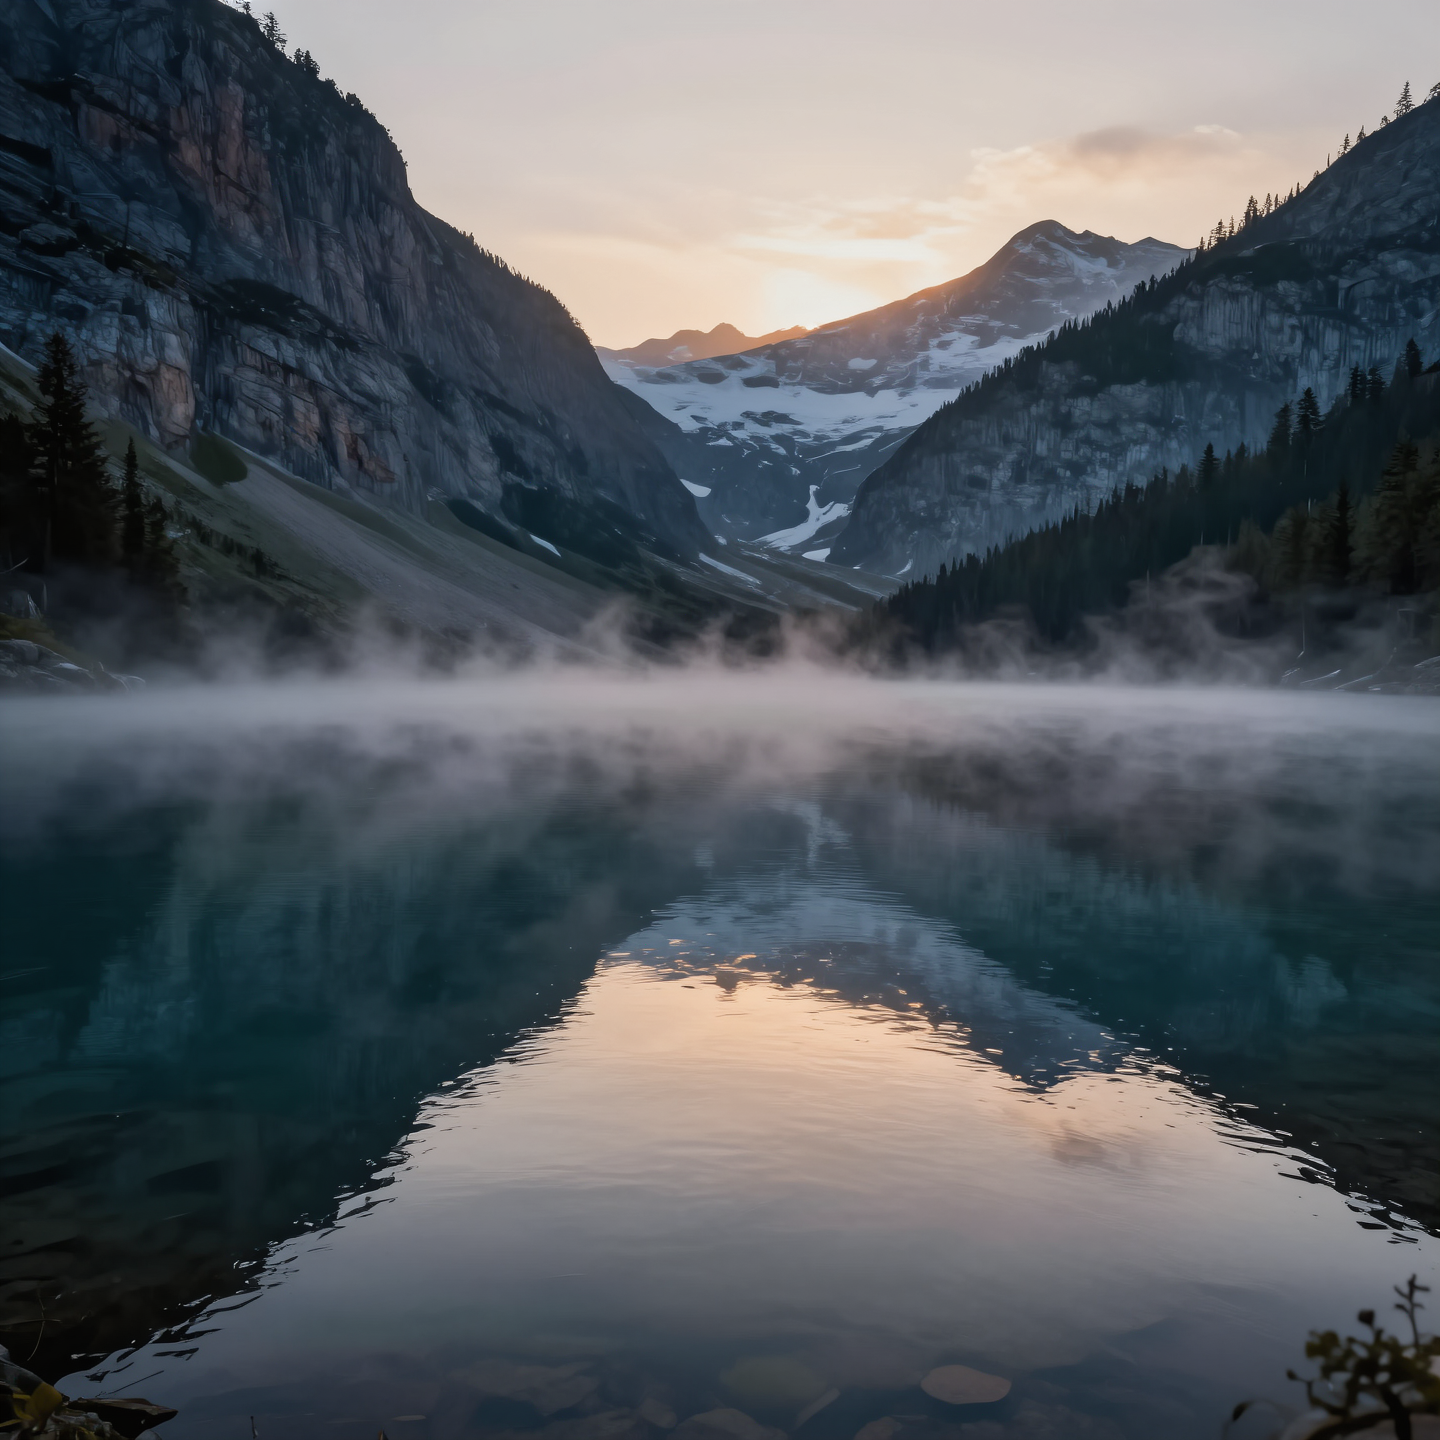

In [0]:
import base64
from IPython.display import display, Image as IPImage
from databricks.sdk import WorkspaceClient

w = WorkspaceClient()
endpoint_name = "microsoft-lens"

response = w.serving_endpoints.query(
    name=endpoint_name,
    dataframe_records=[{"prompt": "A cinematic mountain lake at sunrise, soft mist, detailed reflections"}],
    extra_params={
        "num_inference_steps": 20,
        "guidance_scale": 5.0,
        "base_resolution": 1440,
        "aspect_ratio": "1:1",
        "seed": 42,
    },
)

img_base64 = response.predictions[0]
img_bytes = base64.b64decode(img_base64)
display(IPImage(data=img_bytes))